In [1]:
import pandas as pd

In [2]:
file_path = r"D:\Customer_sentiment_ analysis\data\Reviews.csv"

df = pd.read_csv(file_path)

In [3]:
df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [4]:
df.shape

(568454, 10)

In [5]:
df.columns

Index(['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator',
       'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   Id                      568454 non-null  int64 
 1   ProductId               568454 non-null  object
 2   UserId                  568454 non-null  object
 3   ProfileName             568428 non-null  object
 4   HelpfulnessNumerator    568454 non-null  int64 
 5   HelpfulnessDenominator  568454 non-null  int64 
 6   Score                   568454 non-null  int64 
 7   Time                    568454 non-null  int64 
 8   Summary                 568427 non-null  object
 9   Text                    568454 non-null  object
dtypes: int64(5), object(5)
memory usage: 43.4+ MB


In [7]:
df.isnull().sum()

Id                         0
ProductId                  0
UserId                     0
ProfileName               26
HelpfulnessNumerator       0
HelpfulnessDenominator     0
Score                      0
Time                       0
Summary                   27
Text                       0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df["Score"].value_counts().sort_index()

Score
1     52268
2     29769
3     42640
4     80655
5    363122
Name: count, dtype: int64

In [10]:
df.shape
df.duplicated().sum()
df["Score"].value_counts().sort_index()

Score
1     52268
2     29769
3     42640
4     80655
5    363122
Name: count, dtype: int64

In [11]:
df["Sentiment"] = df["Score"].apply(
    lambda x: "Negative" if x <= 2
    else "Neutral" if x == 3
    else "Positive"
)

In [12]:
df["Sentiment"].value_counts()

Sentiment
Positive    443777
Negative     82037
Neutral      42640
Name: count, dtype: int64

In [13]:
df["Sentiment"].value_counts(normalize=True) * 100

Sentiment
Positive    78.067355
Negative    14.431599
Neutral      7.501047
Name: proportion, dtype: float64

In [15]:
balanced_df = pd.concat([
    df[df["Sentiment"] == "Positive"].sample(n=40000, random_state=42),
    df[df["Sentiment"] == "Negative"].sample(n=40000, random_state=42),
    df[df["Sentiment"] == "Neutral"].sample(n=40000, random_state=42)
])

In [16]:
balanced_df = balanced_df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

In [17]:
balanced_df["Sentiment"].value_counts()


Sentiment
Negative    40000
Positive    40000
Neutral     40000
Name: count, dtype: int64

In [18]:
balanced_df.duplicated().sum()

np.int64(0)

In [19]:
balanced_df["Text"].duplicated().sum()

np.int64(23785)

In [20]:
(balanced_df["Text"].str.strip() == "").sum()

np.int64(0)

In [21]:
balanced_df[["Text", "Score", "Sentiment"]].sample(10, random_state=42)

,Text,Score,Sentiment
71787,Watch out! These bars are much smaller than p...,2,Negative
67218,I gave this product two stars because I don't ...,2,Negative
54066,"If you like a hot, hard chew with little taste...",2,Negative
7168,"A bold, but not a super bold blend. This coffe...",3,Neutral
29618,I found an article in a health magazine about ...,5,Positive
101425,My wife loves these better than the peanut but...,5,Positive
20441,I've been using liquid soap... excuse me... bo...,3,Neutral
2662,"The 8 gram pods do not hold enough coffee, i.e...",1,Negative
20371,I love flavoured tea and it's not too often wh...,1,Negative
108151,Being a fan of Newman's Pineapple salsa for qu...,5,Positive


In [22]:
balanced_df.duplicated().sum()

np.int64(0)

In [23]:
balanced_df["Text"].duplicated().sum()

np.int64(23785)

In [24]:
(balanced_df["Text"].str.strip() == "").sum()

np.int64(0)

In [25]:
(balanced_df["Text"].str.strip() == "").sum()

np.int64(0)

In [26]:
balanced_df["Text"].head(10)

0    Don''t buy it. My dog loves the treat. HOWEVER...
1    I was very disappointed with this purchase! Th...
2    I was disappointed to find out this "Mexican" ...
3    these are the most delicious popcorn chip i ha...
4    I bought this for my little Westie. Every Fall...
5    FYI - I just visited this site and the price o...
6    I had my doubts at first, so I researched it a...
7    I usually order Twinings tea, but I thought I'...
8    If you (like me) have been looking for the Sou...
9    I love fluffy It was great the only thing is t...
Name: Text, dtype: object

In [27]:
import re

def clean_text(text):
    text = str(text)
    
    # Convert to lowercase
    text = text.lower()
    
    # Remove HTML tags
    text = re.sub(r"<.*?>", "", text)
    
    # Remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)
    
    # Remove special characters and numbers
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    
    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()
    
    return text

In [28]:
balanced_df["Clean_Text"] = balanced_df["Text"].apply(clean_text)

In [29]:
balanced_df[["Text", "Clean_Text"]].head(10)

,Text,Clean_Text
0,Don''t buy it. My dog loves the treat. HOWEVER...,dont buy it my dog loves the treat however aft...
1,I was very disappointed with this purchase! Th...,i was very disappointed with this purchase the...
2,"I was disappointed to find out this ""Mexican"" ...",i was disappointed to find out this mexican va...
3,these are the most delicious popcorn chip i ha...,these are the most delicious popcorn chip i ha...
4,I bought this for my little Westie. Every Fall...,i bought this for my little westie every fall ...
5,FYI - I just visited this site and the price o...,fyi i just visited this site and the price of ...
6,"I had my doubts at first, so I researched it a...",i had my doubts at first so i researched it an...
7,"I usually order Twinings tea, but I thought I'...",i usually order twinings tea but i thought id ...
8,If you (like me) have been looking for the Sou...,if you like me have been looking for the south...
9,I love fluffy It was great the only thing is t...,i love fluffy it was great the only thing is t...


In [30]:
import nltk

nltk.download("punkt")
nltk.download("punkt_tab")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\svija\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\svija\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


True

In [31]:
from nltk.tokenize import word_tokenize

balanced_df["Tokens"] = balanced_df["Clean_Text"].apply(word_tokenize)

In [32]:
balanced_df[["Clean_Text", "Tokens"]].head()

,Clean_Text,Tokens
0,dont buy it my dog loves the treat however aft...,"[dont, buy, it, my, dog, loves, the, treat, ho..."
1,i was very disappointed with this purchase the...,"[i, was, very, disappointed, with, this, purch..."
2,i was disappointed to find out this mexican va...,"[i, was, disappointed, to, find, out, this, me..."
3,these are the most delicious popcorn chip i ha...,"[these, are, the, most, delicious, popcorn, ch..."
4,i bought this for my little westie every fall ...,"[i, bought, this, for, my, little, westie, eve..."


In [34]:
balanced_df[["Clean_Text", "Tokens"]].head()

,Clean_Text,Tokens
0,dont buy it my dog loves the treat however aft...,"[dont, buy, it, my, dog, loves, the, treat, ho..."
1,i was very disappointed with this purchase the...,"[i, was, very, disappointed, with, this, purch..."
2,i was disappointed to find out this mexican va...,"[i, was, disappointed, to, find, out, this, me..."
3,these are the most delicious popcorn chip i ha...,"[these, are, the, most, delicious, popcorn, ch..."
4,i bought this for my little westie every fall ...,"[i, bought, this, for, my, little, westie, eve..."


In [35]:
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\svija\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [36]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

In [37]:
balanced_df["Filtered_Tokens"] = balanced_df["Tokens"].apply(
    lambda tokens: [word for word in tokens if word not in stop_words]
)

In [38]:
balanced_df[["Tokens", "Filtered_Tokens"]].head()

,Tokens,Filtered_Tokens
0,"[dont, buy, it, my, dog, loves, the, treat, ho...","[dont, buy, dog, loves, treat, however, found,..."
1,"[i, was, very, disappointed, with, this, purch...","[disappointed, purchase, kcups, came, plain, b..."
2,"[i, was, disappointed, to, find, out, this, me...","[disappointed, find, mexican, vanilla, new, or..."
3,"[these, are, the, most, delicious, popcorn, ch...","[delicious, popcorn, chip, ever, tasted, flavo..."
4,"[i, bought, this, for, my, little, westie, eve...","[bought, little, westie, every, fall, allergys..."


In [39]:
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\svija\AppData\Roaming\nltk_data...
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\svija\AppData\Roaming\nltk_data...


True

In [40]:
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

In [41]:
balanced_df["Lemmatized_Tokens"] = balanced_df["Filtered_Tokens"].apply(
    lambda tokens: [lemmatizer.lemmatize(word) for word in tokens]
)

In [43]:
balanced_df[
    ["Filtered_Tokens", "Lemmatized_Tokens"]
].head()

,Filtered_Tokens,Lemmatized_Tokens
0,"[dont, buy, dog, loves, treat, however, found,...","[dont, buy, dog, love, treat, however, found, ..."
1,"[disappointed, purchase, kcups, came, plain, b...","[disappointed, purchase, kcups, came, plain, b..."
2,"[disappointed, find, mexican, vanilla, new, or...","[disappointed, find, mexican, vanilla, new, or..."
3,"[delicious, popcorn, chip, ever, tasted, flavo...","[delicious, popcorn, chip, ever, tasted, flavo..."
4,"[bought, little, westie, every, fall, allergys...","[bought, little, westie, every, fall, allergy,..."


In [44]:
balanced_df["Processed_Text"] = balanced_df["Lemmatized_Tokens"].apply(
    lambda tokens: " ".join(tokens)
)

In [45]:
balanced_df[
    ["Text", "Clean_Text", "Processed_Text", "Sentiment"]
].head()

,Text,Clean_Text,Processed_Text,Sentiment
0,Don''t buy it. My dog loves the treat. HOWEVER...,dont buy it my dog loves the treat however aft...,dont buy dog love treat however found made chi...,Negative
1,I was very disappointed with this purchase! Th...,i was very disappointed with this purchase the...,disappointed purchase kcups came plain box cup...,Negative
2,"I was disappointed to find out this ""Mexican"" ...",i was disappointed to find out this mexican va...,disappointed find mexican vanilla new orleans ...,Negative
3,these are the most delicious popcorn chip i ha...,these are the most delicious popcorn chip i ha...,delicious popcorn chip ever tasted flavor favo...,Positive
4,I bought this for my little Westie. Every Fall...,i bought this for my little westie every fall ...,bought little westie every fall allergy itchin...,Positive


In [46]:
balanced_df[
    ["Text", "Clean_Text", "Processed_Text", "Sentiment"]
].head()

,Text,Clean_Text,Processed_Text,Sentiment
0,Don''t buy it. My dog loves the treat. HOWEVER...,dont buy it my dog loves the treat however aft...,dont buy dog love treat however found made chi...,Negative
1,I was very disappointed with this purchase! Th...,i was very disappointed with this purchase the...,disappointed purchase kcups came plain box cup...,Negative
2,"I was disappointed to find out this ""Mexican"" ...",i was disappointed to find out this mexican va...,disappointed find mexican vanilla new orleans ...,Negative
3,these are the most delicious popcorn chip i ha...,these are the most delicious popcorn chip i ha...,delicious popcorn chip ever tasted flavor favo...,Positive
4,I bought this for my little Westie. Every Fall...,i bought this for my little westie every fall ...,bought little westie every fall allergy itchin...,Positive


In [47]:
X = balanced_df["Processed_Text"]
y = balanced_df["Sentiment"]

In [48]:
print(X.shape)
print(y.shape)

(120000,)
(120000,)


In [49]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [50]:
print("Training data:", X_train.shape)
print("Testing data :", X_test.shape)

Training data: (96000,)
Testing data : (24000,)


In [51]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    min_df=2
)

In [52]:
X_train_tfidf = vectorizer.fit_transform(X_train)

In [53]:
X_test_tfidf = vectorizer.transform(X_test)

In [54]:
print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape :", X_test_tfidf.shape)

Training TF-IDF shape: (96000, 20000)
Testing TF-IDF shape : (24000, 20000)


In [55]:
vectorizer.fit_transform(X_test)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 1052992 stored elements and shape (24000, 20000)>

In [56]:
print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape :", X_test_tfidf.shape)

Training TF-IDF shape: (96000, 20000)
Testing TF-IDF shape : (24000, 20000)


In [57]:
from sklearn.linear_model import LogisticRegression

In [61]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [62]:
lr_model.fit(X_train_tfidf, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [63]:
y_pred_lr = lr_model.predict(X_test_tfidf)

In [64]:
from sklearn.metrics import accuracy_score

accuracy_lr = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", accuracy_lr)

Logistic Regression Accuracy: 0.76175


In [65]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

    Negative       0.77      0.77      0.77      8000
     Neutral       0.70      0.70      0.70      8000
    Positive       0.82      0.81      0.82      8000

    accuracy                           0.76     24000
   macro avg       0.76      0.76      0.76     24000
weighted avg       0.76      0.76      0.76     24000



In [66]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [67]:
y_pred_nb = nb_model.predict(X_test_tfidf)

In [68]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_nb))

              precision    recall  f1-score   support

    Negative       0.73      0.72      0.72      8000
     Neutral       0.64      0.64      0.64      8000
    Positive       0.78      0.78      0.78      8000

    accuracy                           0.72     24000
   macro avg       0.72      0.72      0.72     24000
weighted avg       0.72      0.72      0.72     24000



In [69]:
from sklearn.svm import LinearSVC

In [70]:
svm_model = LinearSVC(
    random_state=42
)

In [71]:
svm_model.fit(X_train_tfidf, y_train)

,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.0
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,verbose,0
,random_state,42


In [72]:
y_pred_svm = svm_model.predict(X_test_tfidf)

In [73]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

    Negative       0.76      0.77      0.77      8000
     Neutral       0.70      0.68      0.69      8000
    Positive       0.80      0.81      0.81      8000

    accuracy                           0.76     24000
   macro avg       0.76      0.76      0.76     24000
weighted avg       0.76      0.76      0.76     24000



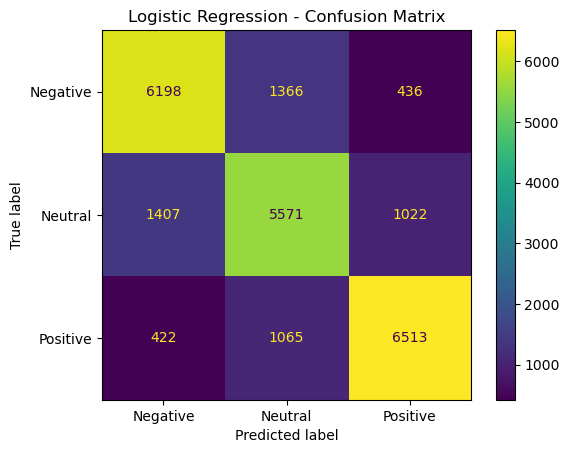

In [74]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    y_pred_lr,
    labels=["Negative", "Neutral", "Positive"]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negative", "Neutral", "Positive"]
)

disp.plot()
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

In [75]:
TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    min_df=2
)

,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None
,analyzer,'word'
,stop_words,None
,token_pattern,'(?u)\\b\\w\\w+\\b'
,ngram_range,"(1, ...)"


In [77]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer_v2 = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True
)

In [78]:
X_train_tfidf_v2 = vectorizer_v2.fit_transform(X_train)

In [79]:
X_test_tfidf_v2 = vectorizer_v2.transform(X_test)

In [80]:
print("Training:", X_train_tfidf_v2.shape)
print("Testing :", X_test_tfidf_v2.shape)

Training: (96000, 50000)
Testing : (24000, 50000)


In [81]:
lr_model_v2 = LogisticRegression(
    C=2,
    max_iter=1000,
    random_state=42
)

In [86]:
lr_model_v2.fit(X_train_tfidf_v2, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,2
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [84]:
from sklearn.linear_model import LogisticRegression

lr_model_v2 = LogisticRegression(
    C=2,
    max_iter=1000,
    random_state=42
)

In [87]:
y_pred_lr_v2 = lr_model_v2.predict(X_test_tfidf_v2)

In [88]:
from sklearn.metrics import accuracy_score

accuracy_lr_v2 = accuracy_score(y_test, y_pred_lr_v2)

print("Improved Logistic Regression Accuracy:", accuracy_lr_v2)

Improved Logistic Regression Accuracy: 0.7809166666666667


In [89]:
print(X_train_tfidf_v2.shape)
print(X_test_tfidf_v2.shape)

(96000, 50000)
(24000, 50000)


In [90]:
results = {
    "Logistic Regression": accuracy_lr,
    "Naive Bayes": accuracy_score(y_test, y_pred_nb),
    "Linear SVM": accuracy_score(y_test, y_pred_svm),
    "Improved Logistic Regression": accuracy_lr_v2
}

results

{'Logistic Regression': 0.76175,
 'Naive Bayes': 0.71625,
 'Linear SVM': 0.7557916666666666,
 'Improved Logistic Regression': 0.7809166666666667}

In [91]:
results_df = pd.DataFrame(
    list(results.items()),
    columns=["Model", "Accuracy"]
)

results_df

,Model,Accuracy
0,Logistic Regression,0.761750
1,Naive Bayes,0.716250
2,Linear SVM,0.755792
3,Improved Logistic Regression,0.780917


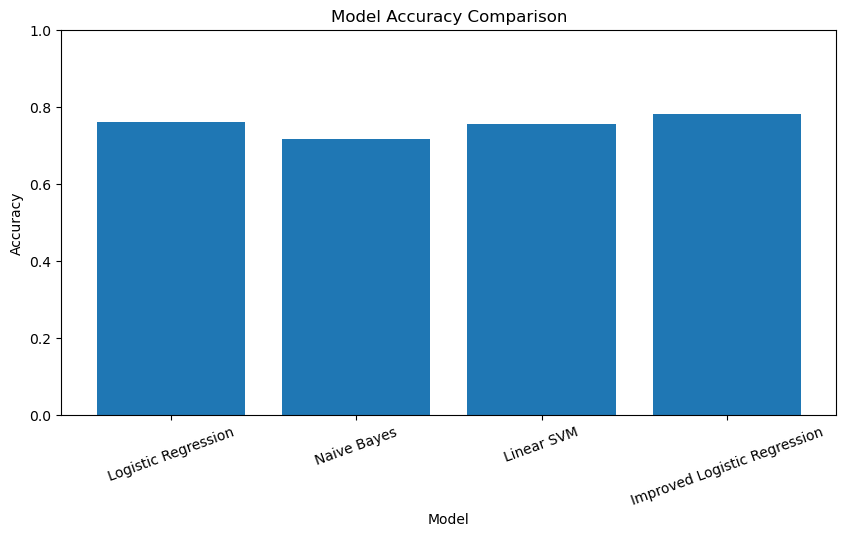

In [92]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.bar(
    results_df["Model"],
    results_df["Accuracy"]
)

plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")

plt.xticks(rotation=20)
plt.ylim(0, 1)

plt.show()

In [93]:
final_model = lr_model_v2
final_predictions = y_pred_lr_v2

In [94]:
final_model = lr_model
final_predictions = y_pred_lr

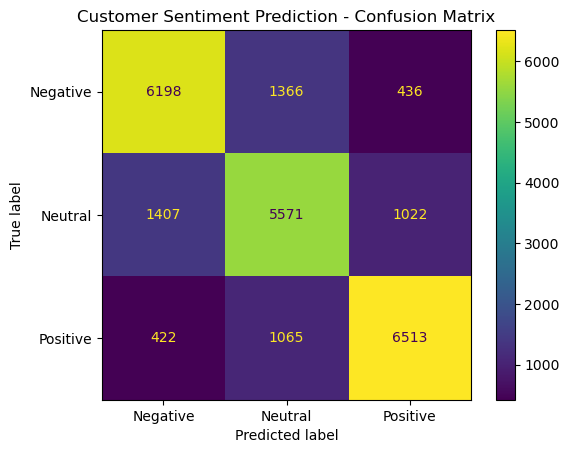

In [95]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(
    y_test,
    final_predictions,
    labels=["Negative", "Neutral", "Positive"]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negative", "Neutral", "Positive"]
)

disp.plot()

plt.title("Customer Sentiment Prediction - Confusion Matrix")
plt.show()

In [96]:
def predict_sentiment(review):

    cleaned = clean_text(review)

    tokens = word_tokenize(cleaned)

    filtered_tokens = [
        word for word in tokens
        if word not in stop_words
    ]

    lemmatized_tokens = [
        lemmatizer.lemmatize(word)
        for word in filtered_tokens
    ]

    processed = " ".join(lemmatized_tokens)

    vectorized = vectorizer.transform([processed])

    prediction = final_model.predict(vectorized)[0]

    return prediction

In [97]:
review = "This product is absolutely amazing. I really loved it!"

print(predict_sentiment(review))

Positive


In [98]:
review = "Very bad product. I am completely disappointed."

print(predict_sentiment(review))

Negative


In [99]:
review = "The product is okay. Nothing special."

print(predict_sentiment(review))

Positive


In [100]:
vectorizer

,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None
,analyzer,'word'
,stop_words,None
,token_pattern,'(?u)\\b\\w\\w+\\b'
,ngram_range,"(1, ...)"


In [101]:
vectorizer_v2

,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None
,analyzer,'word'
,stop_words,None
,token_pattern,'(?u)\\b\\w\\w+\\b'
,ngram_range,"(1, ...)"


In [102]:
import joblib

In [104]:
import os

model_path = r"D:\Customer_sentiment_ analysis\model"

os.makedirs(model_path, exist_ok=True)

print("Model folder created:", model_path)

Model folder created: D:\Customer_sentiment_ analysis\model


In [105]:
import joblib

joblib.dump(
    lr_model,
    r"D:\Customer_sentiment_ analysis\model\sentiment_model.pkl"
)

['D:\\Customer_sentiment_ analysis\\model\\sentiment_model.pkl']

In [106]:
joblib.dump(
    vectorizer,
    r"D:\Customer_sentiment_ analysis\model\tfidf_vectorizer.pkl"
)

['D:\\Customer_sentiment_ analysis\\model\\tfidf_vectorizer.pkl']

In [107]:
print(os.listdir(model_path))

['sentiment_model.pkl', 'tfidf_vectorizer.pkl']


In [108]:
print(os.listdir(model_path))

['sentiment_model.pkl', 'tfidf_vectorizer.pkl']
